# Statistical Forecasting Benchmarks

This notebook benchmarks statistical forecasting models for monthly Zillow home sales counts.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsforecast import StatsForecast
from statsforecast.models import (
    AutoARIMA,
    TBATS,
    AutoMFLES,
    HoltWinters,
    SeasonalNaive
)

## Data

In [2]:
# Data
df = pd.read_csv("Data/zillow_houses_hierarchy_cleaned.csv", parse_dates=["ds"])

data = (df[["unique_id", "ds", "y"]]
    .copy()
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True))

## Forecasting setup

The task is a 12-month-ahead forecast evaluated with five walk-forward validation windows. Since the data are monthly, all seasonal models use a 12-month seasonal period.

In [3]:
# Monthly setup
horizon = 12
n_windows = 5
step_size = 12
freq = "ME"          
season_length = 12

## Calendar regressors

Month indicators are added as known-in-advance regressors for the AutoARIMAX benchmark. These variables capture recurring seasonal effects without using future target values.

In [4]:
# Exogenous features only for ARIMAX 
# These are temporal known-in-advance regressors: month dummies only
data_xreg = data.copy()

month_dummies = pd.get_dummies(data_xreg["ds"].dt.month, prefix="month", drop_first=True, dtype=float)
data_xreg = pd.concat([data_xreg[["unique_id", "ds", "y"]], month_dummies],axis=1)
xreg_cols = [c for c in data_xreg.columns if c not in ["unique_id", "ds", "y"]]

print(xreg_cols)
print("X rank:", np.linalg.matrix_rank(data_xreg[xreg_cols].to_numpy()))
print("X columns:", len(xreg_cols))

['month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12']
X rank: 11
X columns: 11


## Cross-validation

The helper functions standardize the output from StatsForecast, combine in-sample and out-of-sample predictions, and store the validation metadata for later comparison.

In [5]:
def format_statsforecast_forecasts(df_, sample_type, model_cols, freq):
    df_ = df_.copy()
    df_["ds"] = pd.to_datetime(df_["ds"])
    df_["cutoff"] = pd.to_datetime(df_["cutoff"])

    out = df_.melt(id_vars=["unique_id", "ds", "cutoff", "y"],
                   value_vars=model_cols,
                   var_name="model",
                   value_name="forecast")

    out["forecast"] = out["forecast"].clip(lower=0)
    out["type"] = sample_type
    out["frequency"] = freq

    if sample_type == "out_sample":
        out["horizon"] = (
            (out["ds"].dt.year - out["cutoff"].dt.year) * 12
            + (out["ds"].dt.month - out["cutoff"].dt.month)
        )
    else:
        out["horizon"] = np.nan

    return out


def run_statsforecast_cv(models, train_df, model_group, uses_exog=False, exogenous_features=None):
    sf = StatsForecast(models=models, freq=freq, n_jobs=-1)

    t0 = time.perf_counter()

    cv_raw = sf.cross_validation(
        df=train_df,
        h=horizon,
        n_windows=n_windows,
        step_size=step_size,
        refit=True,
        fitted=True,
        id_col="unique_id",
        time_col="ds",
        target_col="y"
    ).reset_index(drop=True)

    cv_time = time.perf_counter() - t0

    id_cols = ["unique_id", "ds", "cutoff", "y"]
    model_cols = [c for c in cv_raw.columns if c not in id_cols]

    cv_out = format_statsforecast_forecasts(
        cv_raw,
        sample_type="out_sample",
        model_cols=model_cols,
        freq=freq
    )

    cv_fitted_raw = sf.cross_validation_fitted_values().reset_index(drop=True)

    cv_in = format_statsforecast_forecasts(
        cv_fitted_raw,
        sample_type="in_sample",
        model_cols=model_cols,
        freq=freq
    )

    pred = pd.concat([cv_in, cv_out], ignore_index=True)

    pred["cv_time_seconds"] = cv_time
    pred["horizon_config"] = horizon
    pred["n_windows"] = n_windows
    pred["step_size"] = step_size
    pred["season_length"] = season_length
    pred["model_group"] = model_group
    pred["uses_exog"] = uses_exog
    pred["exogenous_features"] = ",".join(exogenous_features) if uses_exog else "none"

    print(
        f"✓ {model_group} completed in {cv_time:.2f} seconds | "
        f"{cv_raw['cutoff'].nunique()} windows | {len(cv_raw):,} out-sample rows"
    )

    return pred

## Univariate statistical models

The first benchmark includes statistical models that use only the historical sales series. This group includes seasonal naive, exponential smoothing, TBATS, AutoARIMA, and MFLES.

In [6]:
models_univariate = [
    SeasonalNaive(season_length=season_length, alias="SeasonalNaive"),
    HoltWinters(season_length=season_length, error_type="A", alias="HoltWinters"),
    TBATS(season_length=season_length, alias="TBATS"),
    AutoARIMA(season_length=season_length, alias="AutoARIMA")]

pred_univariate = run_statsforecast_cv(
    models=models_univariate,
    train_df=data,
    model_group="StatsForecast_univariate",
    uses_exog=False)

/Users/albertogudinoochoa/miniforge3/envs/tito/lib/python3.12/site-packages/statsforecast/tbats.py:938: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/Users/albertogudinoochoa/miniforge3/envs/tito/lib/python3.12/site-packages/statsforecast/tbats.py:938: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/Users/albertogudinoochoa/miniforge3/envs/tito/lib/python3.12/site-packages/statsforecast/tbats.py:938: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/Users/albertogudinoochoa/miniforge3/envs/tito/lib/python3.12/site-packages/statsforecast/tbats.py:938: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/Users/albertogudinoochoa/miniforge3/envs/tito/lib/python3.12/site-packages/statsforecast/tbats.py:938: UserWarning: Data contains zero or negative values, disabling Box-Co

✓ StatsForecast_univariate completed in 736.15 seconds | 5 windows | 21,000 out-sample rows


## AutoARIMAX benchmark

AutoARIMAX extends AutoARIMA with monthly calendar regressors. This tests whether explicit seasonal indicators improve the statistical benchmark.

In [8]:
# Autoarimax with exogenous features
models_arimax = [AutoARIMA(season_length=season_length,alias="AutoARIMAX")]
pred_arimax = run_statsforecast_cv(
    models=models_arimax,
    train_df=data_xreg,
    model_group="StatsForecast_arimax",
    uses_exog=True,
    exogenous_features=xreg_cols
)

✓ StatsForecast_arimax completed in 1004.10 seconds | 5 windows | 21,000 out-sample rows


In [9]:
meta = (df[["unique_id", "RegionName", "StateName", "hierarchy_level"]].drop_duplicates("unique_id"))
pred_all = (pd.concat([pred_univariate, pred_arimax], ignore_index=True).merge(meta, on="unique_id", how="left"))

In [10]:
pred_all = pred_all[[
    "unique_id", "ds", "cutoff", "y", "forecast", "model",
    "type", "frequency", "horizon",
    "RegionName", "StateName", "hierarchy_level",
    "cv_time_seconds", "horizon_config", "n_windows",
    "step_size", "season_length", "model_group",
    "uses_exog", "exogenous_features"]]

display(pred_all.head())
print(pred_all["type"].value_counts())
print(pred_all["model"].value_counts())

,unique_id,ds,cutoff,y,forecast,model,type,frequency,horizon,RegionName,StateName,hierarchy_level,cv_time_seconds,horizon_config,n_windows,step_size,season_length,model_group,uses_exog,exogenous_features
0,US,2008-02-29,2021-03-31,174474.0,NaN,SeasonalNaive,in_sample,ME,NaN,United States,NaN,0,736.146911,12,5,12,12,StatsForecast_univariate,False,none
1,US,2008-03-31,2021-03-31,203564.0,NaN,SeasonalNaive,in_sample,ME,NaN,United States,NaN,0,736.146911,12,5,12,12,StatsForecast_univariate,False,none
2,US,2008-04-30,2021-03-31,225601.0,NaN,SeasonalNaive,in_sample,ME,NaN,United States,NaN,0,736.146911,12,5,12,12,StatsForecast_univariate,False,none
3,US,2008-05-31,2021-03-31,248297.0,NaN,SeasonalNaive,in_sample,ME,NaN,United States,NaN,0,736.146911,12,5,12,12,StatsForecast_univariate,False,none
4,US,2008-06-30,2021-03-31,260848.0,NaN,SeasonalNaive,in_sample,ME,NaN,United States,NaN,0,736.146911,12,5,12,12,StatsForecast_univariate,False,none


type
in_sample     1911000
out_sample     126000
Name: count, dtype: int64
model
SeasonalNaive    339500
HoltWinters      339500
TBATS            339500
AutoARIMA        339500
MFLES            339500
AutoARIMAX       339500
Name: count, dtype: int64


In [11]:
pred_all.to_parquet("Data/zillow_statsforecast_cv_predictions.parquet", index=False)

## Forecast visualization

The final plot compares out-of-sample forecasts against observed sales for one selected metropolitan series.

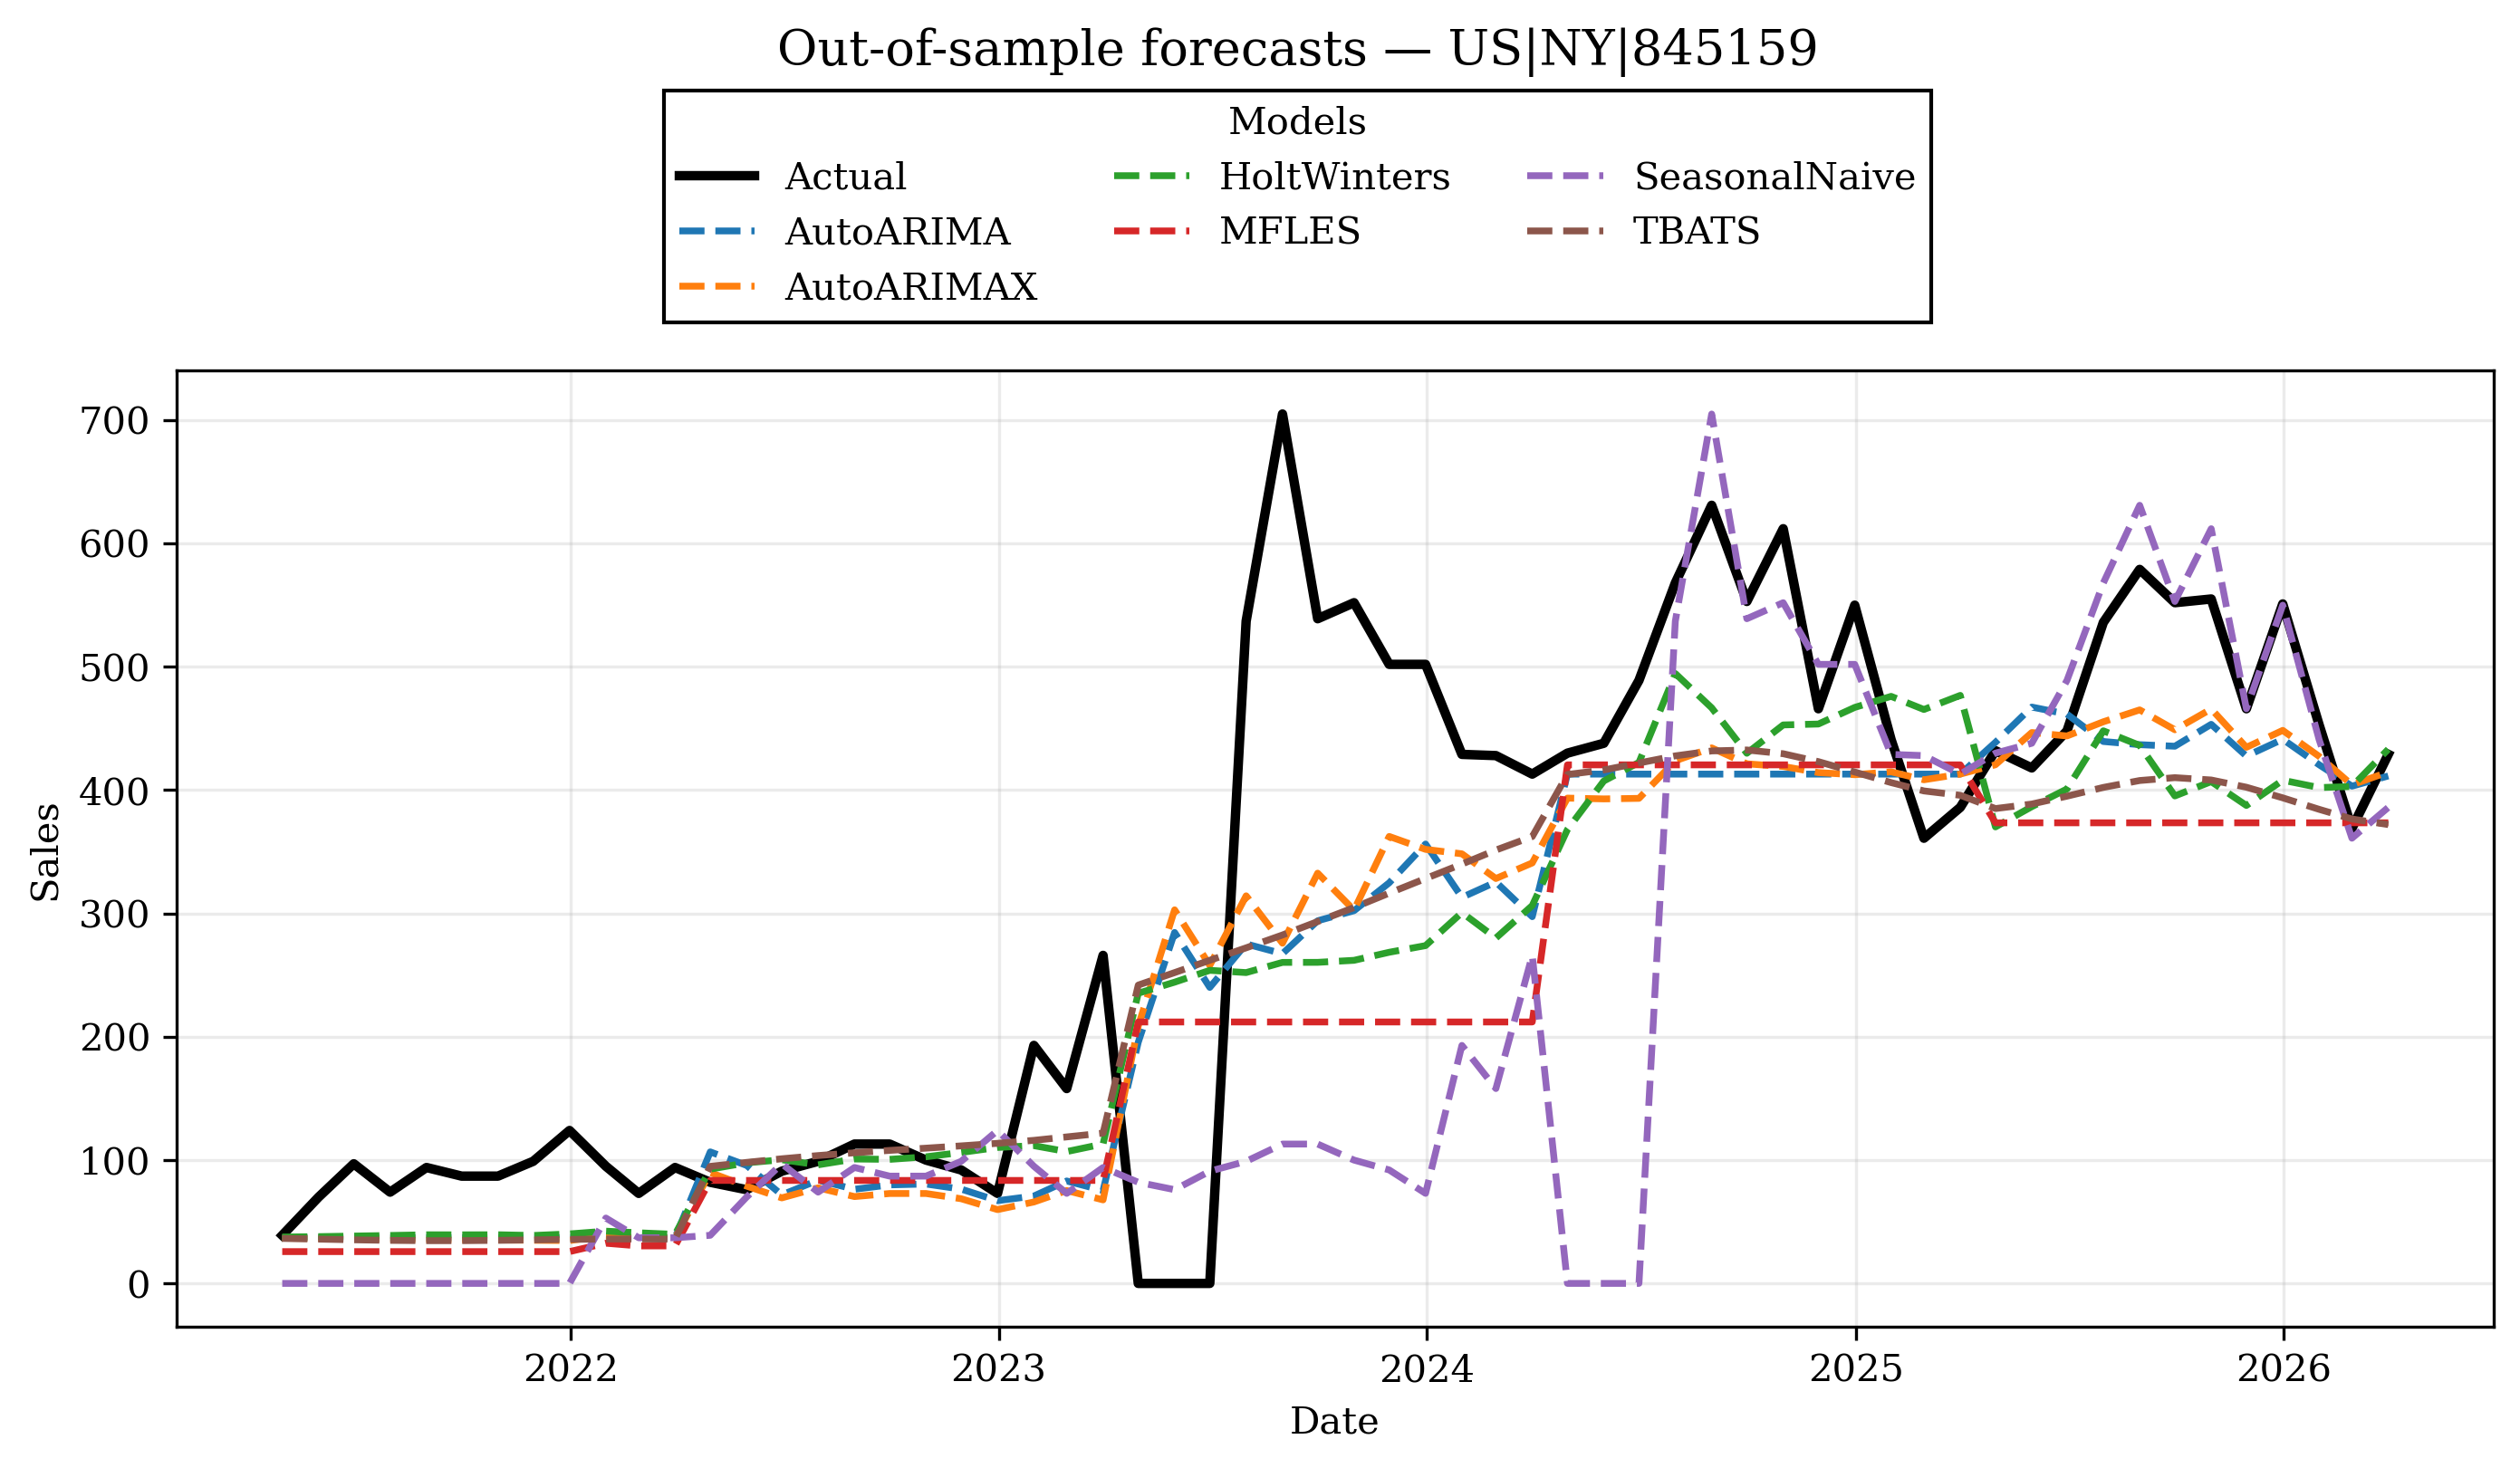

In [12]:
plt.rcParams.update({"font.family": "serif", "figure.dpi": 300})

uid = "US|NY|845159" 

p = (pred_all
    .query("unique_id == @uid and type == 'out_sample'")
    .sort_values(["ds", "model"]))

y_real = p[["ds", "y"]].drop_duplicates().sort_values("ds")
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(y_real["ds"], y_real["y"], color="black", linewidth=2.5, label="Actual")

for model, g in p.groupby("model"):
    g = g.sort_values("ds")
    ax.plot(g["ds"], g["forecast"], "--", linewidth=1.8, label=model)

ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.grid(alpha=0.25)
fig.suptitle(f"Out-of-sample forecasts — {uid}", y=0.98, fontsize=13)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Models", loc="upper center", bbox_to_anchor=(0.5, 0.95), 
           ncol=3, frameon=True, fancybox=False, framealpha=1, edgecolor="black")
fig.subplots_adjust(top=0.75)
plt.show()